# Notebook 3: Skill Extraction
## AI-Powered Job Market Intelligence — Sri Lanka

### What we do here:
- Load cleaned data from Notebook 2
- Extract skills from job descriptions
- Count most demanded skills
- Find top skills per job category
- Save results for Notebook 4

Input  → data/processed/jobs_cleaned.csv
Output → data/processed/jobs_with_skills.csv

In [2]:
# ── IMPORTS ──────────────────────────────────

import pandas as pd
import numpy as np
import re
import os
from collections import Counter    # Counts occurrences of items in a list
import matplotlib.pyplot as plt    # For drawing charts
import seaborn as sns              # For beautiful charts
from tqdm.notebook import tqdm

print("✅ All libraries imported!")

✅ All libraries imported!


In [3]:
# ── SET PATHS ────────────────────────────────

BASE_PATH            = 'D:/Sinali/projects/job_market_intelligence_platform'
RAW_DATA_PATH        = f'{BASE_PATH}/data/raw'
PROCESSED_DATA_PATH  = f'{BASE_PATH}/data/processed'
OUTPUT_PATH          = f'{BASE_PATH}/outputs'

os.makedirs(OUTPUT_PATH, exist_ok=True)

# ── LOAD CLEANED DATA ────────────────────────

print("📂 Loading cleaned data...")

df = pd.read_csv(f'{PROCESSED_DATA_PATH}/jobs_cleaned.csv')

print(f"✅ Data loaded!")
print(f"📊 Rows    : {len(df)}")
print(f"📊 Columns : {len(df.columns)}")
print(f"\n📋 Sample skills column:")
print(df['skills_clean'].head(5).to_string())

📂 Loading cleaned data...
✅ Data loaded!
📊 Rows    : 10000
📊 Columns : 15

📋 Sample skills column:
0    supplier diversity program diversity inclusion...
1    architectural drafting autocad modeling bluepr...
2    art education curriculum program development t...
3    environmental impact analysis data collection ...
4    art education curriculum program development t...


In [11]:
# ── SKILLS DICTIONARY ────────────────────────
# We define skills we want to extract
# organized by category
# The more skills we add the better our analysis

skills_dictionary = {

    'Programming Languages': [
        'python', 'java', 'javascript', 'typescript', 'c++', 'c#',
        'php', 'swift', 'kotlin', 'scala', 'golang', 'ruby',
        'dart', 'bash', 'matlab', 'perl', 'rust', 'assembly'
    ],

    'Web Development': [
        'react', 'angular', 'vue', 'nodejs', 'node', 'django', 'flask',
        'spring', 'laravel', 'html', 'css', 'tailwind', 'bootstrap',
        'redux', 'graphql', 'rest', 'fastapi', 'jquery', 'wordpress',
        'next', 'nuxt', 'express', 'asp.net', 'web development',
        'frontend', 'backend', 'full stack', 'fullstack'
    ],

    'Database': [
        'sql', 'mysql', 'postgresql', 'mongodb', 'redis', 'oracle',
        'sqlite', 'cassandra', 'dynamodb', 'elasticsearch', 'firebase',
        'database', 'nosql', 'data modeling', 'stored procedures'
    ],

    'Cloud & DevOps': [
        'aws', 'azure', 'gcp', 'docker', 'kubernetes', 'jenkins',
        'terraform', 'ansible', 'linux', 'git', 'devops', 'cloud',
        'ci cd', 'github', 'gitlab', 'bitbucket', 'microservices',
        'serverless', 'networking', 'system administration',
        'network administration', 'infrastructure', 'virtualization'
    ],

    'Data Science & ML': [
        'machine learning', 'deep learning', 'tensorflow', 'pytorch',
        'scikit', 'pandas', 'numpy', 'nlp', 'computer vision',
        'statistics', 'tableau', 'power bi', 'excel', 'etl',
        'data analysis', 'data science', 'data visualization',
        'artificial intelligence', 'ai', 'neural network',
        'big data', 'hadoop', 'spark', 'data mining', 'analytics',
        'business intelligence', 'regression', 'classification'
    ],

    'Mobile Development': [
        'flutter', 'react native', 'android', 'ios', 'mobile',
        'swift', 'firebase', 'xamarin', 'mobile development',
        'app development', 'play store', 'app store'
    ],

    'Security': [
        'cybersecurity', 'network security', 'penetration testing',
        'ethical hacking', 'firewall', 'encryption', 'ssl',
        'vulnerability', 'siem', 'soc', 'security', 'compliance',
        'iso 27001', 'incident response'
    ],

    'Design': [
        'figma', 'adobe xd', 'sketch', 'photoshop', 'illustrator',
        'ui design', 'ux design', 'ui ux', 'wireframing', 'prototyping',
        'user research', 'graphic design', 'adobe', 'canva',
        'design thinking', 'user experience', 'user interface'
    ],

    'Project Management': [
        'agile', 'scrum', 'jira', 'kanban', 'project management',
        'product management', 'stakeholder', 'waterfall', 'prince2',
        'pmp', 'risk management', 'budget management'
    ],

    'Soft Skills': [
        'communication', 'teamwork', 'leadership', 'problem solving',
        'analytical', 'collaboration', 'critical thinking',
        'time management', 'attention to detail', 'creativity',
        'adaptability', 'interpersonal', 'presentation',
        'documentation', 'reporting'
    ],

    'Networking': [
        'tcp ip', 'dns', 'dhcp', 'vpn', 'routing', 'switching',
        'cisco', 'network design', 'lan', 'wan', 'wireless',
        'network monitoring', 'load balancing', 'firewall'
    ]
}

total_skills = sum(len(v) for v in skills_dictionary.values())

print(f"✅ Skills dictionary defined!")
print(f"📊 Total categories : {len(skills_dictionary)}")
print(f"📊 Total skills     : {total_skills}")
print(f"\n📋 Categories:")
for category, skills in skills_dictionary.items():
    print(f"   → {category} : {len(skills)} skills")

✅ Skills dictionary defined!
📊 Total categories : 11
📊 Total skills     : 196

📋 Categories:
   → Programming Languages : 18 skills
   → Web Development : 28 skills
   → Database : 15 skills
   → Cloud & DevOps : 23 skills
   → Data Science & ML : 28 skills
   → Mobile Development : 12 skills
   → Security : 14 skills
   → Design : 17 skills
   → Project Management : 12 skills
   → Soft Skills : 15 skills
   → Networking : 14 skills


In [12]:
# ── SKILL EXTRACTION FUNCTION ────────────────

def extract_skills(text):
    """
    Finds skills from our dictionary inside a job text
    
    Example:
    text = 'python developer with django and aws experience'
    returns = ['python', 'django', 'aws']
    """
    if pd.isna(text) or text == '':
        return []
    
    text = str(text).lower()
    found_skills = []
    
    # Check every skill in our dictionary
    for category, skills in skills_dictionary.items():
        for skill in skills:
            # Check if skill exists in text
            if skill.lower() in text:
                found_skills.append(skill)
    
    # Remove duplicates
    found_skills = list(set(found_skills))
    
    return found_skills


# ── TEST IT ──────────────────────────────────
test_text = "python developer with experience in django rest api aws docker and machine learning"

found = extract_skills(test_text)
print(f"TEST TEXT  : {test_text}")
print(f"SKILLS FOUND : {found}")
print(f"TOTAL FOUND  : {len(found)}")

TEST TEXT  : python developer with experience in django rest api aws docker and machine learning
SKILLS FOUND : ['rest', 'aws', 'docker', 'machine learning', 'django', 'python']
TOTAL FOUND  : 6


In [13]:
# ── SKILL EXTRACTION FUNCTION (FIXED) ────────

def extract_skills(text):
    """
    Finds skills from our dictionary inside a job text
    Uses word boundaries to avoid false matches
    Example: 'r' won't match inside 'manager' anymore
    """
    if pd.isna(text) or text == '':
        return []
    
    text = str(text).lower()
    found_skills = []
    
    for category, skills in skills_dictionary.items():
        for skill in skills:
            # \b means word boundary
            # So 'r' only matches the word 'r' not letters inside words
            pattern = r'\b' + re.escape(skill.lower()) + r'\b'
            if re.search(pattern, text):
                found_skills.append(skill)
    
    found_skills = list(set(found_skills))
    return found_skills


# ── TEST IT ──────────────────────────────────
test_text = "python developer with experience in django rest api aws docker and machine learning"

found = extract_skills(test_text)
print(f"TEST TEXT    : {test_text}")
print(f"SKILLS FOUND : {found}")
print(f"TOTAL FOUND  : {len(found)}")

TEST TEXT    : python developer with experience in django rest api aws docker and machine learning
SKILLS FOUND : ['rest', 'aws', 'docker', 'machine learning', 'django', 'python']
TOTAL FOUND  : 6


In [14]:
# ── FILTER IT JOBS ONLY ──────────────────────
# Our skills dictionary is focused on IT skills
# So we need to keep only IT related jobs

it_keywords = [
    'software', 'developer', 'engineer', 'data', 'analyst',
    'designer', 'devops', 'cloud', 'machine learning', 'web',
    'mobile', 'frontend', 'backend', 'fullstack', 'database',
    'network', 'security', 'it ', 'tech', 'programmer', 'architect',
    'python', 'java', 'javascript', 'cyber', 'system', 'digital'
]

def is_it_job(title):
    title = str(title).lower()
    for keyword in it_keywords:
        if keyword in title:
            return True
    return False

# Apply filter
df_it = df[df['title'].apply(is_it_job)].reset_index(drop=True)

print(f"✅ Filtering complete!")
print(f"📊 Total jobs     : {len(df)}")
print(f"📊 IT jobs found  : {len(df_it)}")
print(f"\n📋 Sample IT job titles:")
print(df_it['title'].value_counts().head(10).to_string())

✅ Filtering complete!
📊 Total jobs     : 10000
📊 IT jobs found  : 4301

📋 Sample IT job titles:
title
UX/UI Designer                  288
Digital Marketing Specialist    181
Software Engineer               165
Network Engineer                163
Software Tester                 153
Systems Administrator           110
Network Administrator           106
Graphic Designer                102
Marketing Analyst               100
UI Developer                     96


In [15]:
# ── APPLY SKILL EXTRACTION ON IT JOBS ────────
# Now we use df_it instead of df

print("🔍 Extracting skills from IT jobs...\n")

tqdm.pandas()

# Extract from skills column
print("Step 1/2 → Extracting from skills column...")
df_it['extracted_skills'] = df_it['skills_clean'].progress_apply(extract_skills)

# Extract from description column
print("\nStep 2/2 → Extracting from description column...")
df_it['desc_skills'] = df_it['description_clean'].progress_apply(extract_skills)

# Combine both lists and remove duplicates
print("\n🔗 Combining results...")
df_it['all_skills'] = df_it.apply(
    lambda row: list(set(row['extracted_skills'] + row['desc_skills'])),
    axis=1
)

# Count how many skills found per job
df_it['skill_count'] = df_it['all_skills'].apply(len)

print(f"\n✅ Skill extraction complete!")
print(f"📊 Total IT jobs          : {len(df_it)}")
print(f"📊 Average skills per job : {df_it['skill_count'].mean():.1f}")
print(f"📊 Max skills in one job  : {df_it['skill_count'].max()}")
print(f"📊 Min skills in one job  : {df_it['skill_count'].min()}")
print(f"\n📋 Sample:")
df_it[['title', 'all_skills', 'skill_count']].head(5)

🔍 Extracting skills from IT jobs...

Step 1/2 → Extracting from skills column...


  0%|          | 0/4301 [00:00<?, ?it/s]


Step 2/2 → Extracting from description column...


  0%|          | 0/4301 [00:00<?, ?it/s]


🔗 Combining results...

✅ Skill extraction complete!
📊 Total IT jobs          : 4301
📊 Average skills per job : 3.4
📊 Max skills in one job  : 13
📊 Min skills in one job  : 0

📋 Sample:


,title,all_skills,skill_count
0,Architectural Designer,[collaboration],1
1,Architect,[],0
2,Network Engineer,"[infrastructure, security, network security]",3
3,IT Manager,"[aws, network administration, virtualization, ...",8
4,Network Administrator,"[communication, incident response, firewall, e...",8


In [16]:
# ── COUNT MOST DEMANDED SKILLS ───────────────
# We flatten all skill lists into one big list
# Then count how many times each skill appears

all_skills_flat = []

for skills_list in df_it['all_skills']:
    all_skills_flat.extend(skills_list)  # Add each skill to the big list

# Count occurrences of each skill
skill_counts = Counter(all_skills_flat)

# Convert to DataFrame for easy viewing
skills_df = pd.DataFrame(
    skill_counts.most_common(30),  # Top 30 skills
    columns=['skill', 'count']
)

# Calculate percentage
skills_df['percentage'] = (skills_df['count'] / len(df_it) * 100).round(1)

print(f"✅ Skill counting complete!")
print(f"📊 Unique skills found : {len(skill_counts)}")
print(f"\n📋 TOP 30 MOST DEMANDED SKILLS:")
print("=" * 45)
print(f"{'Skill':<25} {'Count':>6} {'% of Jobs':>10}")
print("=" * 45)
for _, row in skills_df.iterrows():
    print(f"{row['skill']:<25} {row['count']:>6} {row['percentage']:>9}%")

✅ Skill counting complete!
📊 Unique skills found : 105

📋 TOP 30 MOST DEMANDED SKILLS:
Skill                      Count  % of Jobs
problem solving              753      17.5%
security                     748      17.4%
communication                707      16.4%
infrastructure               569      13.2%
data analysis                507      11.8%
user interface               456      10.6%
python                       426       9.9%
database                     418       9.7%
prototyping                  398       9.3%
sql                          381       8.9%
wireframing                  353       8.2%
collaboration                347       8.1%
adobe                        295       6.9%
compliance                   280       6.5%
java                         269       6.3%
reporting                    262       6.1%
analytics                    257       6.0%
network security             243       5.6%
data visualization           241       5.6%
data modeling                226 

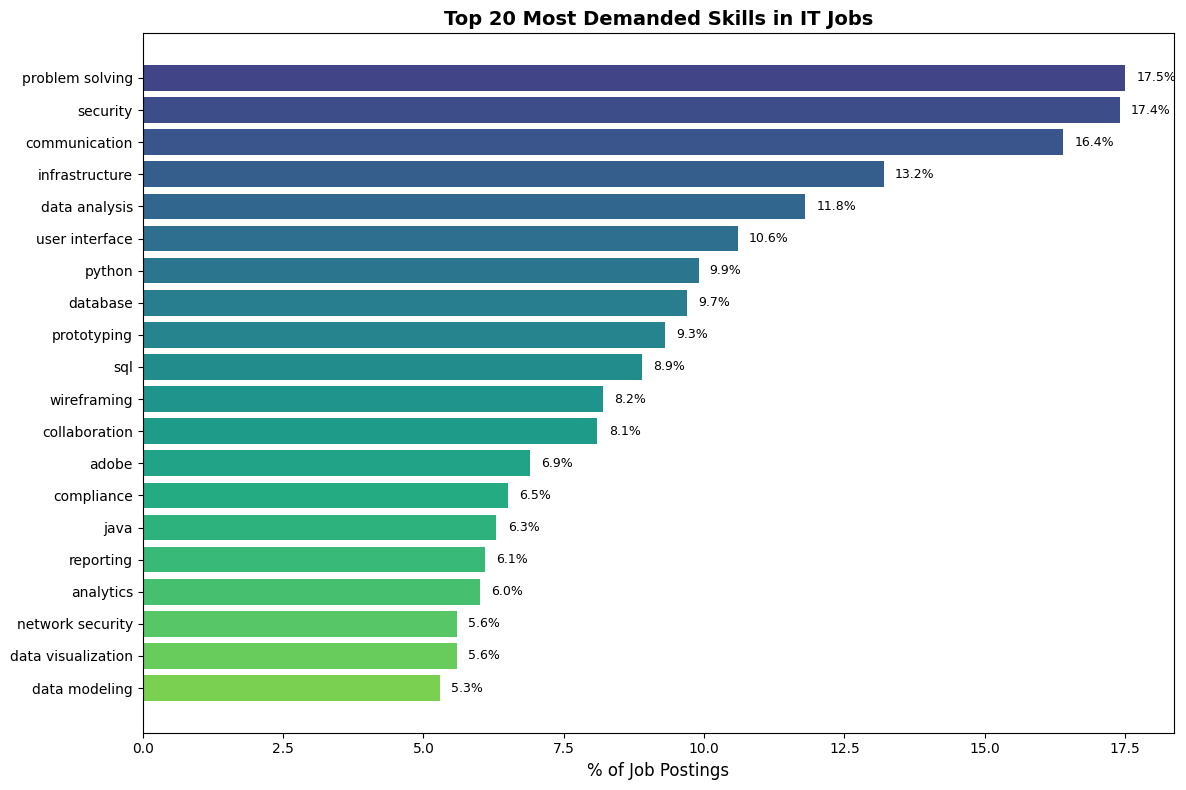

✅ Chart saved to: D:/Sinali/projects/job_market_intelligence_platform/outputs/top_skills.png


In [19]:
# ── VISUALIZE TOP SKILLS ─────────────────────

plt.figure(figsize=(12, 8))

# Create horizontal bar chart
colors = plt.cm.viridis_r(np.linspace(0.2, 0.8, 20))

bars = plt.barh(
    skills_df['skill'].head(20)[::-1],
    skills_df['percentage'].head(20)[::-1],
    color=colors
)

# Add value labels on bars
for bar, val in zip(bars, skills_df['percentage'].head(20)[::-1]):
    plt.text(
        bar.get_width() + 0.2,
        bar.get_y() + bar.get_height()/2,
        f'{val}%',
        va='center',
        fontsize=9
    )

plt.xlabel('% of Job Postings', fontsize=12)
plt.title('Top 20 Most Demanded Skills in IT Jobs', fontsize=14, fontweight='bold')
plt.tight_layout()

# Save chart
chart_path = f'{OUTPUT_PATH}/top_skills.png'
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Chart saved to: {chart_path}")

📋 SKILLS BY CATEGORY:
Category                   Count        %
Soft Skills                 2496    58.0%
Design                      2469    57.4%
Security                    1883    43.8%
Data Science & ML           1761    40.9%
Cloud & DevOps              1649    38.3%
Database                    1284    29.9%
Web Development             1246    29.0%
Programming Languages       1031    24.0%
Project Management           267     6.2%
Networking                   256     6.0%
Mobile Development           195     4.5%


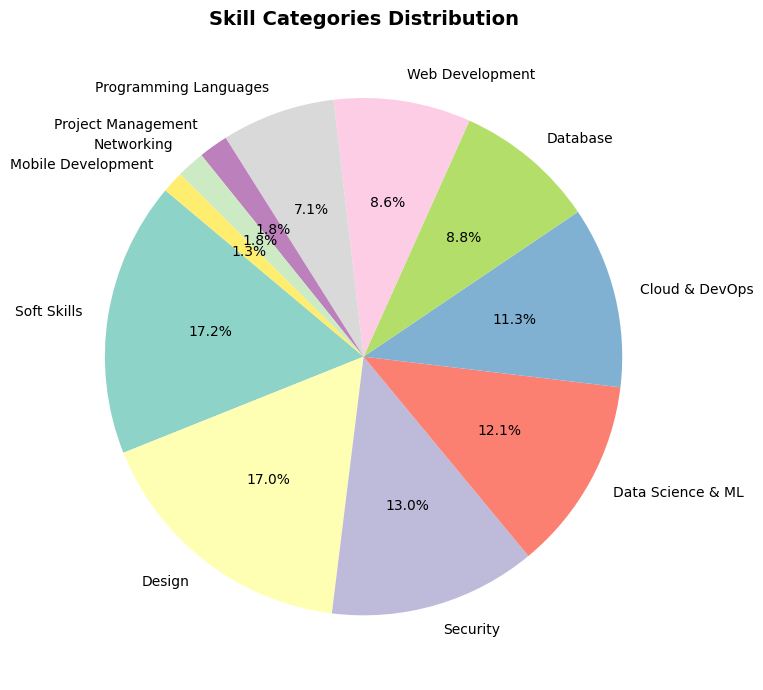


✅ Chart saved to: D:/Sinali/projects/job_market_intelligence_platform/outputs/skill_categories.png


In [20]:
# ── SKILLS BY CATEGORY ───────────────────────
# Count how many times each CATEGORY appears

category_counts = {}

for category, skills in skills_dictionary.items():
    count = 0
    for skill in skills:
        count += skill_counts.get(skill, 0)
    category_counts[category] = count

# Convert to DataFrame
category_df = pd.DataFrame(
    list(category_counts.items()),
    columns=['category', 'count']
).sort_values('count', ascending=False)

category_df['percentage'] = (category_df['count'] / len(df_it) * 100).round(1)

print("📋 SKILLS BY CATEGORY:")
print("=" * 45)
print(f"{'Category':<25} {'Count':>6} {'%':>8}")
print("=" * 45)
for _, row in category_df.iterrows():
    print(f"{row['category']:<25} {row['count']:>6} {row['percentage']:>7}%")

# ── PIE CHART ────────────────────────────────
plt.figure(figsize=(10, 7))

plt.pie(
    category_df['count'],
    labels=category_df['category'],
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.Set3(np.linspace(0, 1, len(category_df)))
)

plt.title('Skill Categories Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()

chart_path = f'{OUTPUT_PATH}/skill_categories.png'
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Chart saved to: {chart_path}")

In [21]:
# ── TOP SKILLS PER JOB TITLE ─────────────────
# Find most demanded skills for each job role

top_titles = df_it['title'].value_counts().head(6).index.tolist()

print("📋 TOP SKILLS PER JOB ROLE:")
print("=" * 50)

title_skills = {}

for title in top_titles:
    # Filter jobs for this title
    title_jobs = df_it[df_it['title'] == title]
    
    # Flatten all skills for this title
    title_skills_flat = []
    for skills_list in title_jobs['all_skills']:
        title_skills_flat.extend(skills_list)
    
    # Count top 5 skills
    top_5 = Counter(title_skills_flat).most_common(5)
    title_skills[title] = top_5
    
    print(f"\n {title} ({len(title_jobs)} jobs)")
    print(f"   Top skills:")
    for skill, count in top_5:
        pct = round(count / len(title_jobs) * 100, 1)
        print(f"   → {skill:<25} {pct}%")

print("\n✅ Done!")

📋 TOP SKILLS PER JOB ROLE:

 UX/UI Designer (288 jobs)
   Top skills:
   → prototyping               68.1%
   → wireframing               68.1%
   → adobe                     57.6%
   → user experience           42.4%
   → graphic design            31.9%

 Digital Marketing Specialist (181 jobs)
   Top skills:
   → analytics                 89.5%
   → compliance                10.5%

 Software Engineer (165 jobs)
   Top skills:
   → infrastructure            60.0%
   → python                    60.0%
   → frontend                  40.0%
   → javascript                40.0%
   → user interface            40.0%

 Network Engineer (163 jobs)
   Top skills:
   → security                  100.0%
   → network security          89.6%
   → infrastructure            73.6%
   → penetration testing       16.0%
   → firewall                  16.0%

 Software Tester (153 jobs)
   Top skills:
   → reporting                 48.4%
   → regression                48.4%
   → python                    34.

In [22]:
# ── SAVE FINAL DATA ──────────────────────────

# Convert skills list to string for saving
# Lists can't be saved directly to CSV
df_it['all_skills_str'] = df_it['all_skills'].apply(lambda x: ', '.join(x))

save_path = f'{PROCESSED_DATA_PATH}/jobs_with_skills.csv'
df_it.to_csv(save_path, index=False)

print(f"✅ Data saved!")
print(f"📁 Location  : {save_path}")
print(f"📊 Rows      : {len(df_it)}")
print(f"📊 Columns   : {len(df_it.columns)}")
print(f"\n📊 SUMMARY OF NOTEBOOK 3:")
print(f"   Total IT jobs analyzed  : {len(df_it)}")
print(f"   Unique skills found     : {len(skill_counts)}")
print(f"   Top demanded skill      : {skills_df.iloc[0]['skill']} ({skills_df.iloc[0]['percentage']}%)")
print(f"   Top skill category      : {category_df.iloc[0]['category']} ({category_df.iloc[0]['percentage']}%)")
print(f"\n Charts saved to    : {OUTPUT_PATH}")
print(f"\n🎉 Notebook 3 Complete!")
print(f"👉 Next step → Notebook 4: Model Training")

✅ Data saved!
📁 Location  : D:/Sinali/projects/job_market_intelligence_platform/data/processed/jobs_with_skills.csv
📊 Rows      : 4301
📊 Columns   : 20

📊 SUMMARY OF NOTEBOOK 3:
   Total IT jobs analyzed  : 4301
   Unique skills found     : 105
   Top demanded skill      : problem solving (17.5%)
   Top skill category      : Soft Skills (58.0%)

 Charts saved to    : D:/Sinali/projects/job_market_intelligence_platform/outputs

🎉 Notebook 3 Complete!
👉 Next step → Notebook 4: Model Training
